In [5]:
import cv2
from matplotlib import pyplot
import numpy

# Ustawienie rozmarów wyświetlanych obrazów
pyplot.rcParams["figure.figsize"] = (18, 10)

In [8]:
#
# Wczytanie obrazów źródłowych
#
# źródło grafiki colors.jpg: https://unsplash.com/photos/gT5kuls6Y6Q
# źródło grafiki gacław-na-kuchni.jpg: własne
#
image_from_file = cv2.imread('images/colors.jpg')
#image_from_file = cv2.imread('images/gacław-na-kuchni.jpg')
image_gray = cv2.cvtColor(image_from_file, cv2.COLOR_BGR2GRAY)
image_color = cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB)
print('Rozmiar obrazka: ', image_from_file.shape)

Rozmiar obrazka:  (750, 1000, 3)


# Zadanie 1

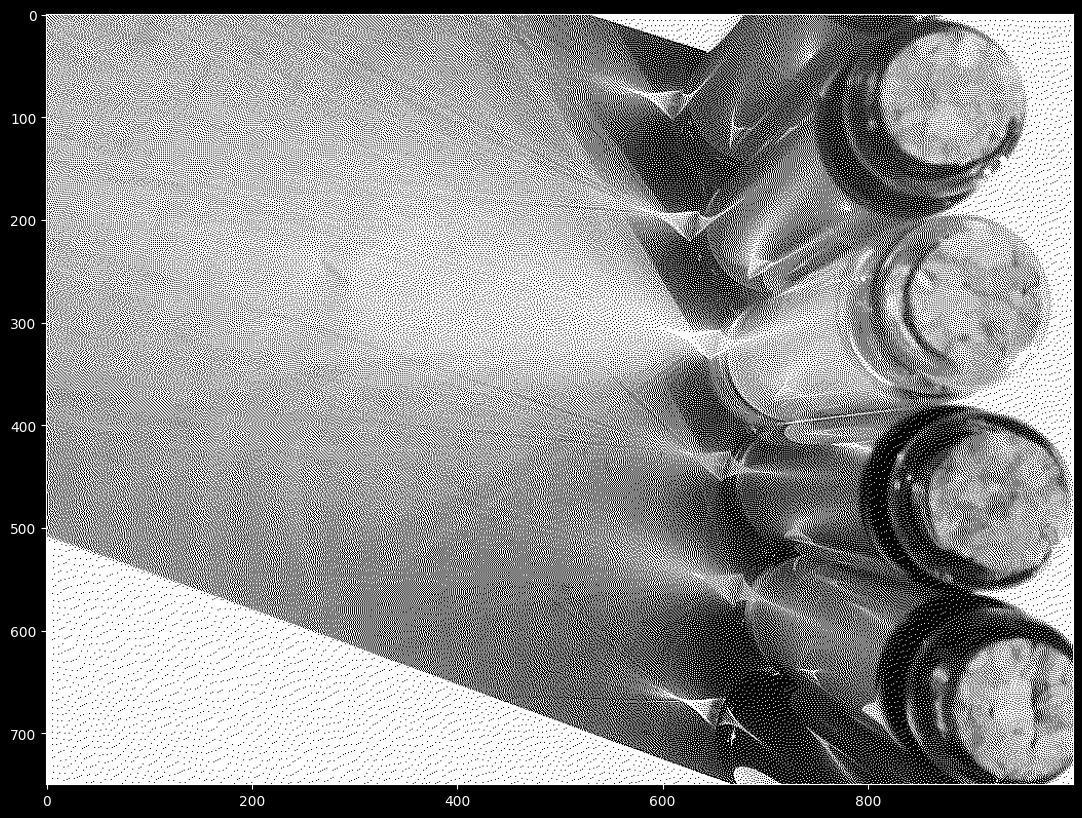

In [11]:
def find_closest_palette_color(value):
    return round(value / 255) * 255

output = image_gray.astype(numpy.float32).copy()

#
# Algorytm
#
for y in range(output.shape[0]):
    for x in range(output.shape[1]):
        oldpixel = output[y, x]
        newpixel = find_closest_palette_color(oldpixel)
        output[y,x] = newpixel
        error = oldpixel-newpixel

        if x + 1 < output.shape[1]:
            output[y, x + 1] = numpy.clip(output[y, x + 1] + error * 7 / 16,0, 255)

        if y + 1 < output.shape[0]:
            if x - 1 >= 0:
                output[y + 1, x - 1] = numpy.clip(output[y + 1, x - 1] + error * 3/16, 0, 255)
            output[y + 1, x] = numpy.clip(output[y + 1, x] + error * 5 / 16, 0, 255)
            if x + 1 < output.shape[1]:
                output[y + 1, x + 1] = numpy.clip(output[y + 1, x + 1] + error * 1/16, 0, 255)
output = output.astype(numpy.uint8)

#
# Wyświetlenie
#
pyplot.imshow(output, cmap='gray')

Text(0, 0.5, 'Liczba pikseli obrazu []')

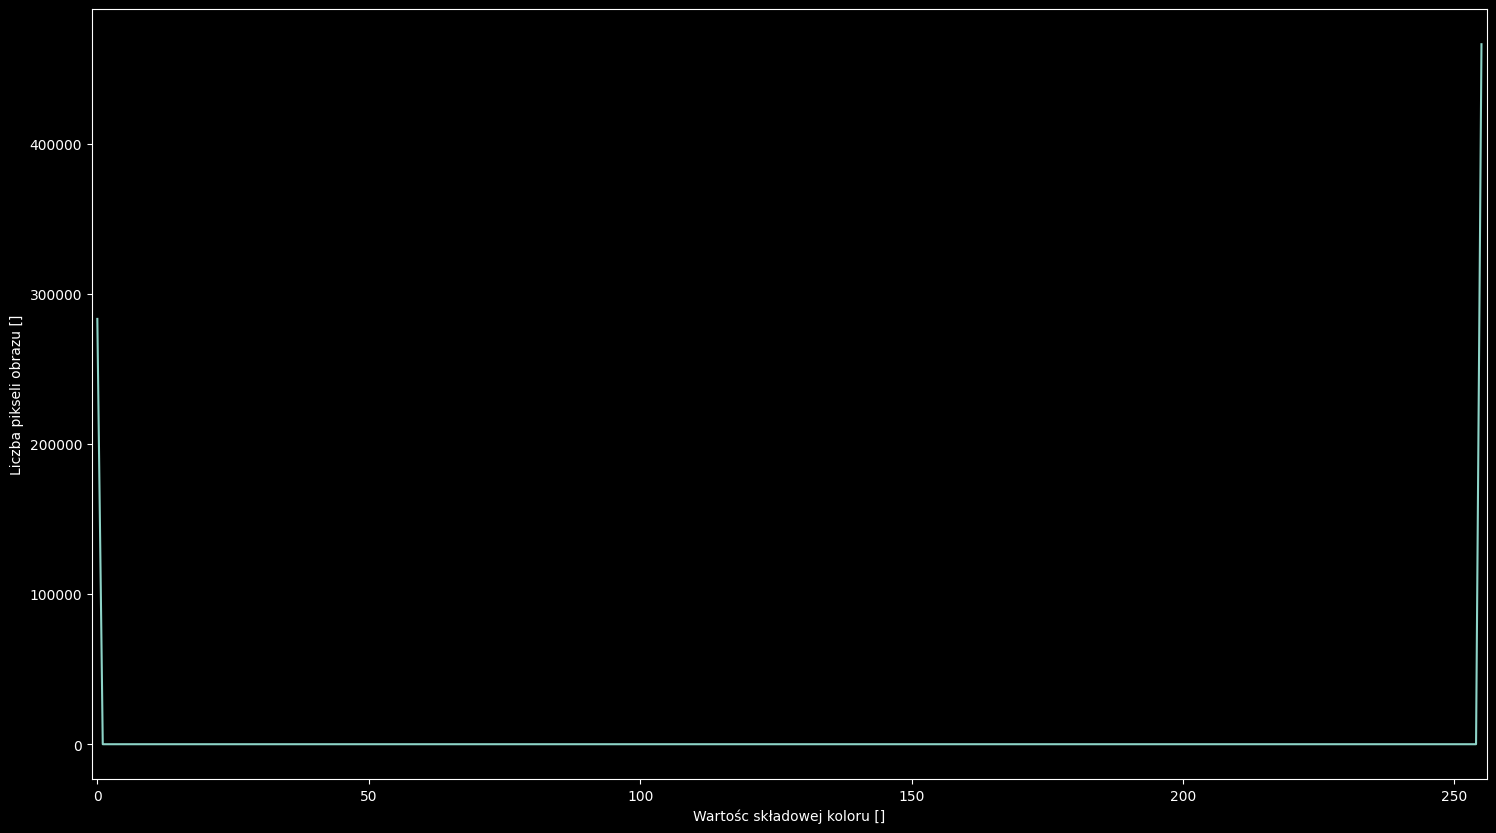

In [12]:
#
# Histogram
#
histr = cv2.calcHist([output], [0], None, [256], [0, 256])
pyplot.plot(histr)
pyplot.xlim([-1, 256])
pyplot.xlabel('Wartośc składowej koloru []')
pyplot.ylabel('Liczba pikseli obrazu []')

# Zadanie 2

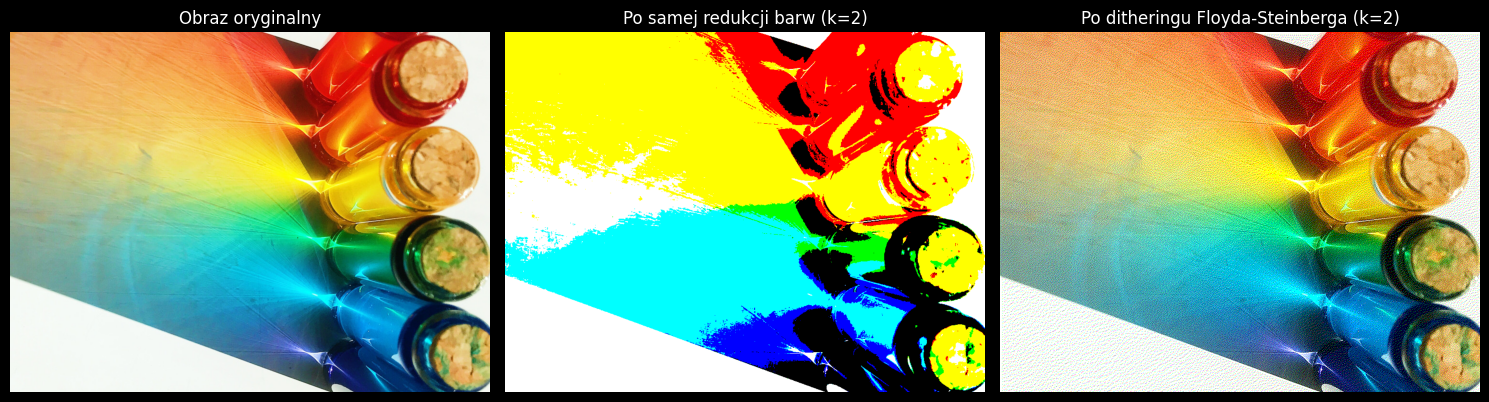

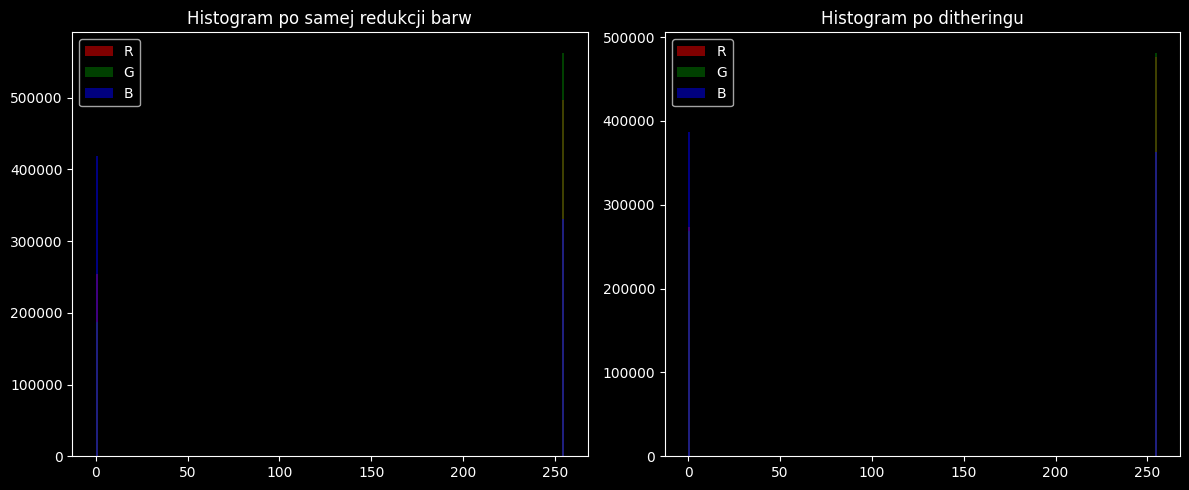

In [16]:
def find_closest_palette_color(value,k=2):
    return round((k - 1) * value / 255) * 255 / (k - 1)
def quantize_pixel(pixel, k=2):
    return numpy.array([
        find_closest_palette_color(pixel[0], k),
        find_closest_palette_color(pixel[1], k),
        find_closest_palette_color(pixel[2], k)
], dtype=numpy.float32)

k = 2
reduced = image_color.astype(numpy.float32).copy()
for y in range(reduced.shape[0]):
    for x in range(reduced.shape[1]):
        reduced[y, x] = quantize_pixel(reduced[y, x], k)

reduced = numpy.clip(reduced, 0, 255).astype(numpy.uint8)


output = image_color.astype(numpy.float32).copy()

#
# Algorytm
#
for y in range(output.shape[0]):
    for x in range(output.shape[1]):
        oldpixel = output[y, x].copy()
        newpixel = quantize_pixel(oldpixel,k)
        output[y,x] = newpixel
        error = oldpixel-newpixel

        if x + 1 < output.shape[1]:
            output[y, x + 1] = numpy.clip(output[y, x + 1] + error * 7 / 16,0, 255)

        if y + 1 < output.shape[0]:
            if x - 1 >= 0:
                output[y + 1, x - 1] = numpy.clip(output[y + 1, x - 1] + error * 3/16, 0, 255)

            output[y + 1, x] = numpy.clip(output[y + 1, x] + error * 5 / 16, 0, 255)

            if x + 1 < output.shape[1]:
                output[y + 1, x + 1] = numpy.clip(output[y + 1, x + 1] + error * 1/16, 0, 255)
output = output.astype(numpy.uint8)


pyplot.figure(figsize=(15, 5))
pyplot.subplot(1, 3, 1)
pyplot.imshow(image_color)
pyplot.title('Obraz oryginalny')
pyplot.axis('off')
pyplot.subplot(1, 3, 2)
pyplot.imshow(reduced)
pyplot.title(f'Po samej redukcji barw (k={k})')
pyplot.axis('off')
pyplot.subplot(1, 3, 3)
pyplot.imshow(output)
pyplot.title(f'Po ditheringu Floyda-Steinberga (k={k})')
pyplot.axis('off')
pyplot.tight_layout()
pyplot.show()


pyplot.figure(figsize=(12, 5))
pyplot.subplot(1, 2, 1)
pyplot.hist(reduced[:, :, 0].ravel(), bins=256, alpha=0.5, color='red', label='R')
pyplot.hist(reduced[:, :, 1].ravel(), bins=256, alpha=0.5, color='green', label='G')
pyplot.hist(reduced[:, :, 2].ravel(), bins=256, alpha=0.5, color='blue', label='B')
pyplot.title('Histogram po samej redukcji barw')
pyplot.legend()
pyplot.subplot(1, 2, 2)
pyplot.hist(output[:, :, 0].ravel(), bins=256, alpha=0.5, color='red', label='R')
pyplot.hist(output[:, :, 1].ravel(), bins=256, alpha=0.5, color='green', label='G')
pyplot.hist(output[:, :, 2].ravel(), bins=256, alpha=0.5, color='blue', label='B')
pyplot.title('Histogram po ditheringu')
pyplot.legend()
pyplot.tight_layout()
pyplot.show()

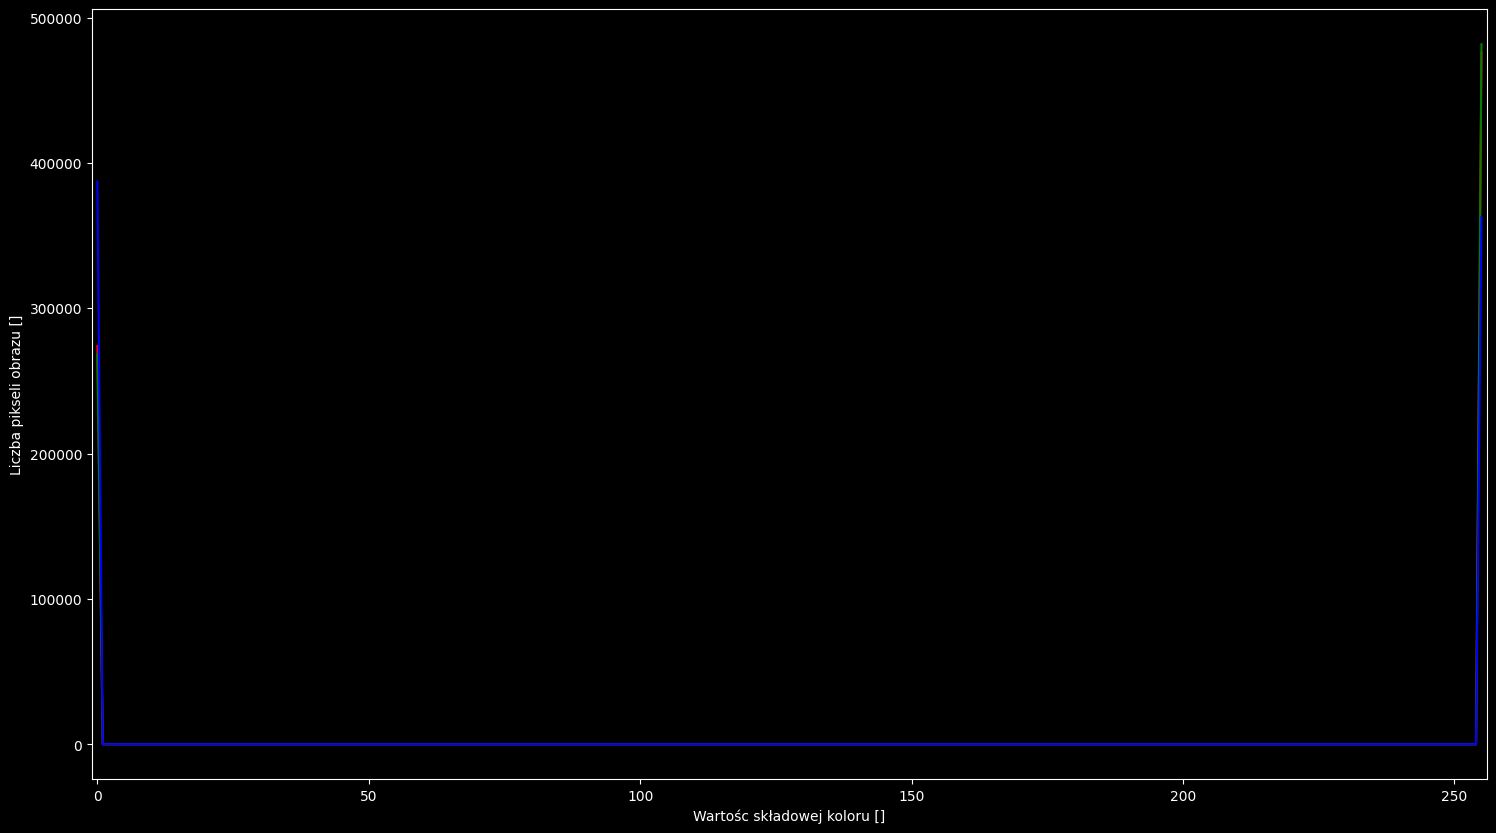

In [17]:
#
# Histogram
#
color = ('r', 'g', 'b')

for i, col in enumerate(color):
    histr = cv2.calcHist([output], [i], None, [256], [0, 256])
    pyplot.plot(histr, color=col)
    pyplot.xlim([-1, 256])
    pyplot.xlabel('Wartośc składowej koloru []')
    pyplot.ylabel('Liczba pikseli obrazu []')

# Zadanie 3

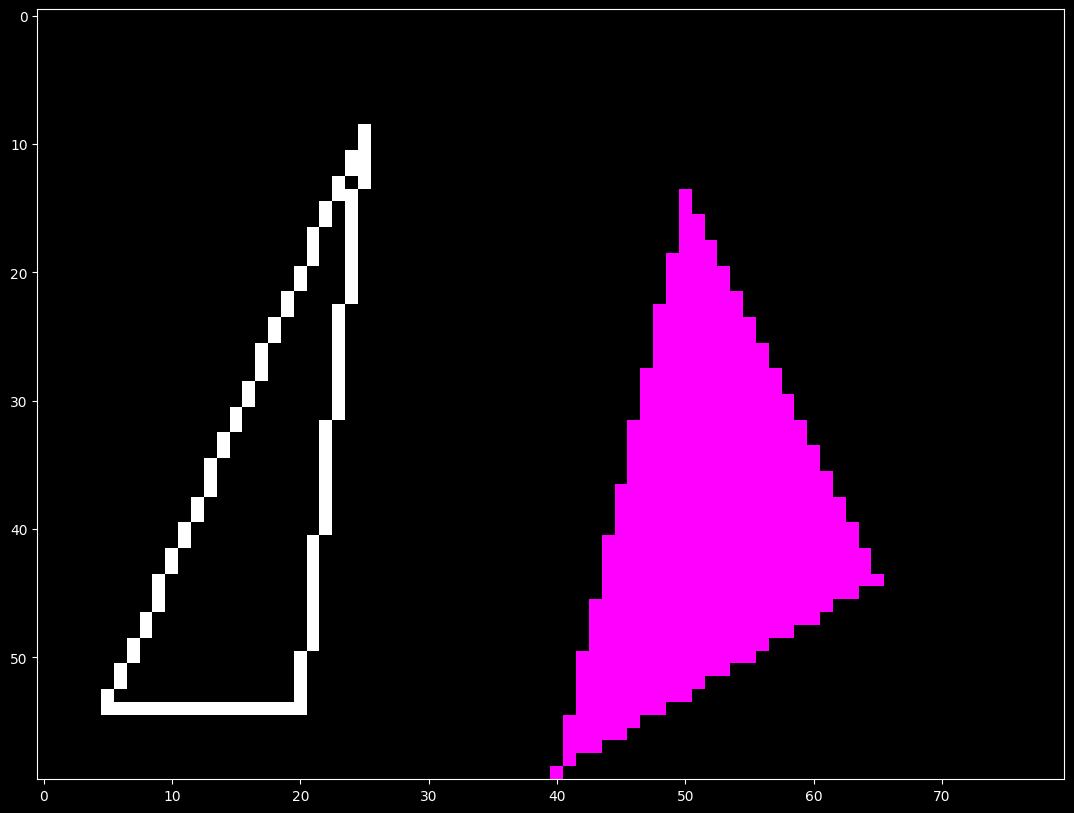

In [29]:
#
# Przygotowanie płótna
#
width = 80
height = 60
image = numpy.zeros((height, width, 3), dtype=numpy.uint8)


#
# Funkcja rysująca punkt
#
# NOTE(sdatko): punkt 0,0 to lewy dolny róg obrazu
#
def draw_point(image, x, y, color=(255, 255, 255)):
    image[image.shape[0] - 1 - y, x, :] = color


#
# Funkcja rysująca linię
#
def draw_line(image, x1, y1, x2, y2, color=(255, 255, 255)):
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    if x1 < x2:
        sx = 1
    else:
        sx = -1

    if y1 < y2:
        sy = 1
    else:
        sy = -1

    err = dx - dy

    x = x1
    y = y1

    while True:
        draw_point(image, x, y, color)

        if x == x2 and y == y2:
            break

        e2 = 2 * err

        if e2 > -dy:
            err = err - dy
            x = x + sx

        if e2 < dx:
            err = err + dx
            y = y + sy

def area(a, b, c):
    return (c[0] - a[0]) * (b[1] - a[1]) - (c[1] - a[1]) * (b[0] - a[0])


def is_inside_triangle(p, a, b, c):
    area1 = area(a, b, p)
    area2 = area(b, c, p)
    area3 = area(c, a, p)

    has_negative = area1 < 0 or area2 < 0 or area3 < 0
    has_positive = area1 > 0 or area2 > 0 or area3 > 0

    return not (has_negative and has_positive)

#
# Funkcja rysująca trójkąt
#
def draw_triangle(image, a, b, c, color=(0, 0, 255)):
    xmin = max(0, min(a[0], b[0], c[0]))
    xmax = min(image.shape[1] - 1, max(a[0], b[0], c[0]))

    ymin = max(0, min(a[1], b[1], c[1]))
    ymax = min(image.shape[0] - 1, max(a[1], b[1], c[1]))

    for y in range(ymin, ymax + 1):
        for x in range(xmin, xmax + 1):
            p = (x, y)

            if is_inside_triangle(p, a, b, c):
                draw_point(image, x, y, color)


#
# Rysowanie
#
draw_line(image, 5, 5, 25, 50, color=(255, 255, 255))
draw_line(image, 5, 5, 20, 5, color=(255, 255, 255))
draw_line(image, 20, 5, 25, 50, color=(255, 255, 255))



draw_triangle(image, (40, 0), (65, 15), (50, 45), color=(255, 0, 255))

#
# Wyświetlenie
#
pyplot.imshow(image)


# Zadanie 4

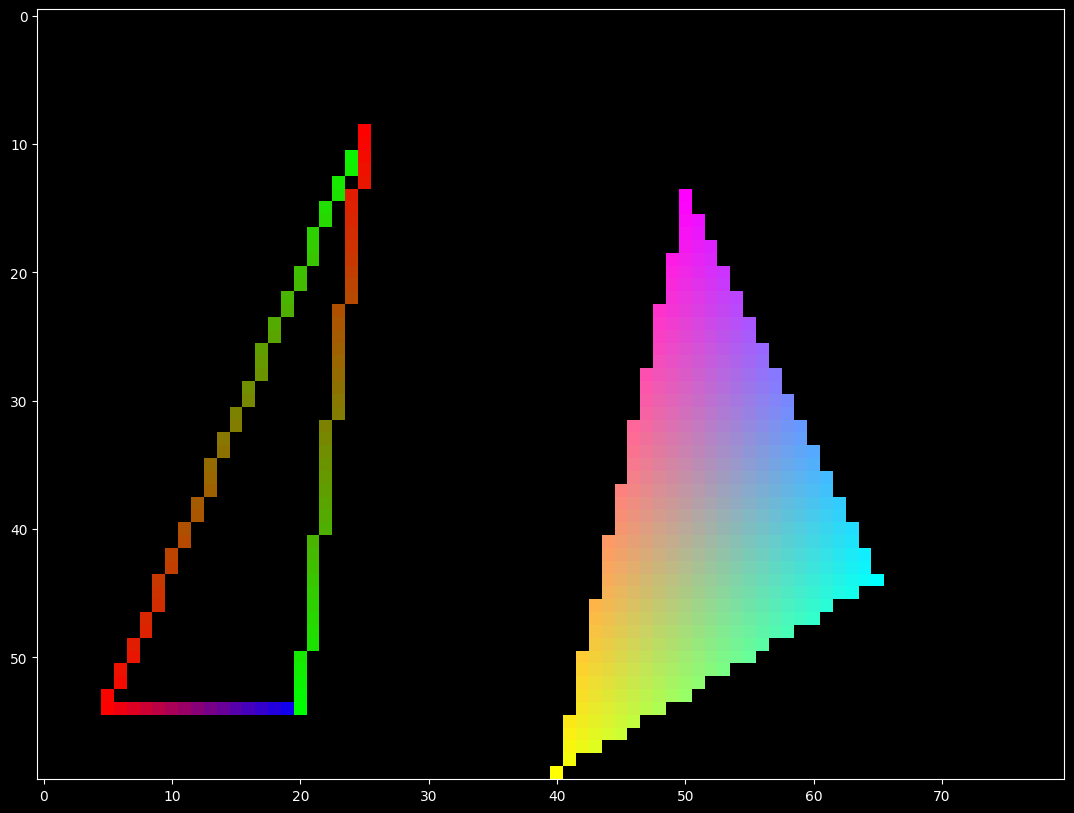

In [41]:
#
# Przygotowanie płótna
#
width = 80
height = 60
image = numpy.zeros((height, width, 3), dtype=numpy.uint8)


#
# Funkcja rysująca punkt
#
# NOTE(sdatko): punkt 0,0 to lewy dolny róg obrazu
#
def draw_point(image, x, y, color=(255, 255, 255)):
    image[image.shape[0] - 1 - y, x, :] = color

def interpolate_color(c1, c2, t):
    c1 = numpy.array(c1, dtype=numpy.float32)
    c2 = numpy.array(c2, dtype=numpy.float32)
    return c1 + t * (c2 - c1)

#
# Funkcja rysująca linię
#
def draw_line(image, x1, y1, color1, x2, y2, color2):
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    if x1 < x2:
        sx = 1
    else:
        sx = -1

    if y1 < y2:
        sy = 1
    else:
        sy = -1

    err = dx - dy

    x = x1
    y = y1
    points = []

    while True:
        points.append((x, y))

        if x == x2 and y == y2:
            break

        e2 = 2 * err

        if e2 > -dy:
            err = err - dy
            x = x + sx

        if e2 < dx:
            err = err + dx
            y = y + sy

    for i in range(len(points)):
        if len(points) == 1:
            t = 0
        else:
            t = i / (len(points) - 1)

        color = interpolate_color(color1, color2, t)
        draw_point(image, points[i][0], points[i][1], color)

def area(a, b, c):
    return (c[0] - a[0]) * (b[1] - a[1]) - (c[1] - a[1]) * (b[0] - a[0])


def is_inside_triangle(p, a, b, c):
    area1 = area(a, b, p)
    area2 = area(b, c, p)
    area3 = area(c, a, p)

    has_negative = area1 < 0 or area2 < 0 or area3 < 0
    has_positive = area1 > 0 or area2 > 0 or area3 > 0

    return not (has_negative and has_positive)

#
# Funkcja rysująca trójkąt
#
def draw_triangle(image, a, color0, b,color1, c,color2):
    color0 = numpy.array(color0, dtype=numpy.float32)
    color1 = numpy.array(color1, dtype=numpy.float32)
    color2 = numpy.array(color2, dtype=numpy.float32)
    xmin = max(0, min(a[0], b[0], c[0]))
    xmax = min(image.shape[1] - 1, max(a[0], b[0], c[0]))

    ymin = max(0, min(a[1], b[1], c[1]))
    ymax = min(image.shape[0] - 1, max(a[1], b[1], c[1]))


    triangle_area = area(a, b, c)
    if triangle_area == 0:
        return

    for y in range(ymin, ymax + 1):
        for x in range(xmin, xmax + 1):
            p = (x, y)

            w0 = area(b, c, p) / triangle_area
            w1 = area(c, a, p) / triangle_area
            w2 = area(a, b, p) / triangle_area

            if w0 >= 0 and w1 >= 0 and w2 >= 0:
                color = w0 * color0 + w1 * color1 + w2 * color2
                draw_point(image, x, y, color)





#
# Rysowanie
#
draw_line(image, 5, 5, (255,0,0), 25, 50, (0,255,0))
draw_line(image, 5, 5, (255,0,0), 20, 5, (0,0,255))
draw_line(image, 20, 5, (0,255,0), 25, 50, (255,0,0))

draw_triangle(image,(40, 0),(255, 255, 0),(65, 15),(0, 255, 255),(50, 45),(255, 0, 255))

#
# Wyświetlenie
#
pyplot.imshow(image)


# Zadanie 5

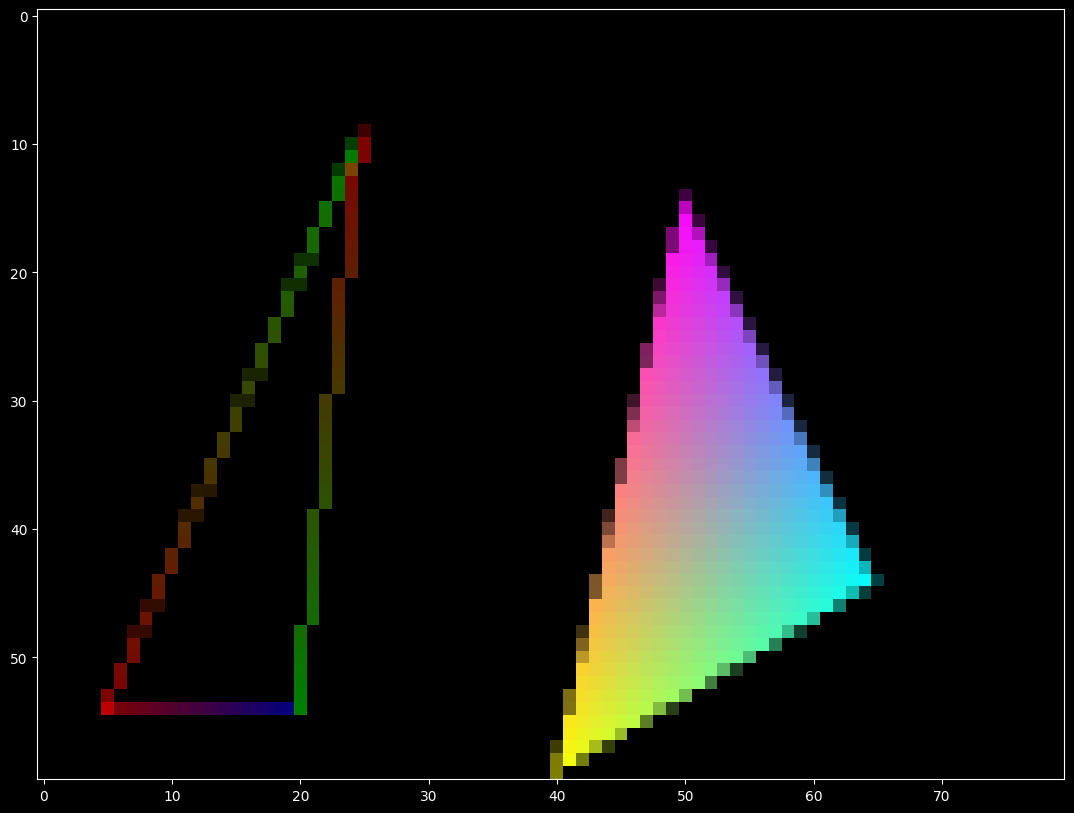

In [42]:
#
# Przygotowanie płótna
#
width = 80
height = 60
scale = 2
image = numpy.zeros((height, width, 3), dtype=numpy.uint8)
image_bigger = numpy.zeros((height * scale, width * scale, 3), dtype=numpy.uint8)

#
# Funkcja rysująca punkt
#
# NOTE(sdatko): punkt 0,0 to lewy dolny róg obrazu
#
def draw_point(image, x, y, color=(255, 255, 255)):
    image[image.shape[0] - 1 - y, x, :] = color

def interpolate_color(c1, c2, t):
    c1 = numpy.array(c1, dtype=numpy.float32)
    c2 = numpy.array(c2, dtype=numpy.float32)
    return c1 + t * (c2 - c1)

#
# Funkcja rysująca linię
#
def draw_line(image, x1, y1, color1, x2, y2, color2):
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    if x1 < x2:
        sx = 1
    else:
        sx = -1

    if y1 < y2:
        sy = 1
    else:
        sy = -1

    err = dx - dy

    x = x1
    y = y1
    points = []

    while True:
        points.append((x, y))

        if x == x2 and y == y2:
            break

        e2 = 2 * err

        if e2 > -dy:
            err = err - dy
            x = x + sx

        if e2 < dx:
            err = err + dx
            y = y + sy

    for i in range(len(points)):
        if len(points) == 1:
            t = 0
        else:
            t = i / (len(points) - 1)

        color = interpolate_color(color1, color2, t)
        draw_point(image, points[i][0], points[i][1], color)

def area(a, b, c):
    return (c[0] - a[0]) * (b[1] - a[1]) - (c[1] - a[1]) * (b[0] - a[0])


def is_inside_triangle(p, a, b, c):
    area1 = area(a, b, p)
    area2 = area(b, c, p)
    area3 = area(c, a, p)

    has_negative = area1 < 0 or area2 < 0 or area3 < 0
    has_positive = area1 > 0 or area2 > 0 or area3 > 0

    return not (has_negative and has_positive)

#
# Funkcja rysująca trójkąt
#
def draw_triangle(image, a, color0, b,color1, c,color2):
    color0 = numpy.array(color0, dtype=numpy.float32)
    color1 = numpy.array(color1, dtype=numpy.float32)
    color2 = numpy.array(color2, dtype=numpy.float32)
    xmin = max(0, min(a[0], b[0], c[0]))
    xmax = min(image.shape[1] - 1, max(a[0], b[0], c[0]))

    ymin = max(0, min(a[1], b[1], c[1]))
    ymax = min(image.shape[0] - 1, max(a[1], b[1], c[1]))


    triangle_area = area(a, b, c)
    if triangle_area == 0:
        return

    for y in range(ymin, ymax + 1):
        for x in range(xmin, xmax + 1):
            p = (x, y)

            w0 = area(b, c, p) / triangle_area
            w1 = area(c, a, p) / triangle_area
            w2 = area(a, b, p) / triangle_area

            if w0 >= 0 and w1 >= 0 and w2 >= 0:
                color = w0 * color0 + w1 * color1 + w2 * color2
                draw_point(image, x, y, color)

def s(x):
    return x*scale

def downsample(img):
    img = img.astype(numpy.float32)
    result = (
        img[0::2, 0::2, :] +
        img[1::2, 0::2, :] +
        img[0::2, 1::2, :] +
        img[1::2, 1::2, :]) / 4

    return result.astype(numpy.uint8)



#
# Rysowanie
#
draw_line(image_bigger, s(5), s(5), (255,0,0), s(25), s(50), (0,255,0))
draw_line(image_bigger, s(5), s(5), (255,0,0), s(20), s(5), (0,0,255))
draw_line(image_bigger, s(20), s(5), (0,255,0), s(25), s(50), (255,0,0))

draw_triangle(image_bigger,(s(40), s(0)), (255, 255, 0),(s(65), s(15)), (0, 255, 255),(s(50),s(45)),(255, 0, 255))

image = downsample(image_bigger)
#
# Wyświetlenie
#
pyplot.imshow(image)
